# Исходный кейс №10: воспроизводимый эксперимент

Выполняется из чистого kernel. Источник — реальные архивные записи AirData.kz / Казгидромет. **PARTIAL:** метрология канала не подтверждена; PM2.5 часто выше PM10. Это не система санитарных предупреждений.

Прочитайте DATA_CARD.md и Report.md. ИИ-помощь раскрыта на уровне пакета.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
case = Path.cwd()
assert (case / 'DATA_CARD.md').exists()
shared_code = case.parent / '01_Air_Pollution'
sys.path.insert(0, str(shared_code))
import pipeline
print('Case:', case.name)
print('Pinned archive commit:', pipeline.COMMIT)

Case: 02_Air_Quality_Prediction
Pinned archive commit: 0fe9a615baf614346e282796f685ce72b852187f


## Реальное выполнение

Следующая ячейка готовит данные, обучает все предусмотренные конфигурации, выбирает по validation и сохраняет test predictions. Результаты не подставлены заранее.

In [2]:
summary = pipeline.run_case2()
display(summary)

{'station_id': '32',
 'station_name': 'PCP #8',
 'city': 'Atyrau',
 'calendar_days': 1461,
 'valid_target_days': 1209,
 'modeled_days': 1108,
 'excluded_missing_lag1_or_lag7': 101,
 'selected_model': 'persistence',
 'MAE_improvement_vs_persistence_pct': 0.0,
 'test_n': 273,
 'shared_source_case': '01_Air_Pollution',
 'status': 'PARTIAL',
 'material_limitation': 'Calibration/channel consistency unresolved; retrospective provider QC and real-time latency unknown; offline forecasting experiment only.'}

## Данные и схема

Target никогда не интерполируется; временная сетка сохраняет реальные пропуски.

In [3]:
dataset = pd.read_csv(case / 'dataset.csv')
print('Rows:', len(dataset), 'Columns:', len(dataset.columns))
display(dataset.head())
display(dataset.isna().sum().rename('missing'))

Rows: 1108 Columns: 17


,date,value_ugm3,lag1,lag2,lag3,lag7,lag14,rolling_mean3,rolling_mean7,rolling_mean14,rolling_std7,sin_doy,cos_doy,sin_week,cos_week,latest_feature_date,split
0,2022-01-19,74.120687,76.357225,67.210639,70.823708,80.224486,87.714975,71.463857,69.915501,72.140436,6.673079,0.321058,0.947060,0.974928,-0.222521,2022-01-18,train
1,2022-01-20,58.049231,74.120687,76.357225,67.210639,63.880896,NaN,72.562850,69.043530,70.441150,5.373795,0.337301,0.941397,0.433884,-0.900969,2022-01-19,train
2,2022-01-21,60.816056,58.049231,74.120687,76.357225,61.268111,NaN,69.509048,68.210435,69.064270,6.616009,0.353445,0.935455,-0.433884,-0.900969,2022-01-20,train
3,2022-01-22,76.232188,60.816056,58.049231,74.120687,69.643444,NaN,64.328658,68.145856,68.239448,6.696781,0.369484,0.929237,-0.974928,-0.222521,2022-01-21,train
4,2022-01-23,78.998785,76.232188,60.816056,58.049231,70.823708,NaN,65.032492,69.087105,68.966061,7.371405,0.385413,0.922744,-0.781831,0.623490,2022-01-22,train


date                    0
value_ugm3              0
lag1                    0
lag2                   24
lag3                   27
lag7                    0
lag14                  66
rolling_mean3           6
rolling_mean7           2
rolling_mean14          1
rolling_std7            2
sin_doy                 0
cos_doy                 0
sin_week                0
cos_week                0
latest_feature_date     0
split                   0
Name: missing, dtype: int64

## Разделение и validation

In [4]:
display(json.loads((case/'results/splits.json').read_text(encoding='utf8')))
display(pd.read_csv(case/'results/validation_metrics.csv'))

{'test': {'start': '2025-01-21', 'end': '2025-12-22', 'n': 273},
 'train': {'start': '2022-01-19', 'end': '2023-12-31', 'n': 631},
 'validation': {'start': '2024-01-01', 'end': '2024-10-08', 'n': 204}}

,MAE,RMSE,R2,n,model
0,8.086033,11.038012,0.521255,204,ridge_0.1
1,8.051830,10.990960,0.525328,204,ridge_1.0
2,7.974059,10.866340,0.536031,204,ridge_10.0
3,12.889865,19.673409,-0.520835,204,forest_3
4,12.525062,19.178143,-0.445226,204,forest_10
5,6.273256,9.033534,0.679345,204,persistence
6,10.100472,14.509623,0.172753,204,seasonal_naive7


## Независимый test

Все варианты сравниваются по одинаковым target. Победитель validation не меняется по test.

In [5]:
pred = pd.read_csv(case/'results/predictions.csv')
metrics = pd.read_csv(case/'results/metrics.csv')
display(metrics)
display(pred.head())
for row in metrics.itertuples():
    actual = pipeline.metric(pred.actual, pred[row.model])
    assert abs(actual['MAE']-row.MAE) < 1e-9
    assert abs(actual['RMSE']-row.RMSE) < 1e-9
print('Metrics recalculated from saved predictions: PASS')

,model,MAE,RMSE,R2,n
0,persistence,3.685881,4.862666,0.633304,273
1,seasonal_naive7,5.194822,6.613189,0.321766,273
2,ridge,3.735623,5.127228,0.592317,273
3,forest,4.287448,5.269900,0.569313,273


,forecast_origin,target_date,actual,latest_feature_date,persistence,seasonal_naive7,ridge,forest
0,2025-01-21T00:00:00+05:00,2025-01-21,49.203743,2025-01-20,40.738931,33.614951,41.003817,42.078305
1,2025-01-22T00:00:00+05:00,2025-01-22,41.895208,2025-01-21,49.203743,33.267153,43.717269,43.681054
2,2025-01-23T00:00:00+05:00,2025-01-23,42.888486,2025-01-22,41.895208,30.545354,42.958825,43.190943
3,2025-01-24T00:00:00+05:00,2025-01-24,38.350764,2025-01-23,42.888486,33.910146,43.277071,45.758108
4,2025-01-25T00:00:00+05:00,2025-01-25,35.425104,2025-01-24,38.350764,40.949556,42.011534,43.576666


Metrics recalculated from saved predictions: PASS


## Признаки строго до target

Это собственная проверка кода. Ретроспективная очистка и реальная доступность upstream не проверяемы.

In [6]:
date = pd.to_datetime(dataset.date)
latest = pd.to_datetime(dataset.latest_feature_date)
assert (latest < date).all()
assert not dataset.value_ugm3.isna().any()
assert not dataset[['lag1','lag7']].isna().any().any()
print('Feature dates and actual-target availability: PASS')
display(pd.read_csv(case/'results/seasonal_metrics.csv'))
display(pd.read_csv(case/'results/largest_errors.csv').head())

Feature dates and actual-target availability: PASS


,season,model,MAE,RMSE,R2,n
0,Весна,persistence,4.813852,6.347860,-0.023446,89
1,Весна,seasonal_naive7,6.135641,7.804097,-0.546876,89
2,Весна,ridge,3.890549,5.214868,0.309288,89
3,Весна,forest,4.230156,5.355443,0.271548,89
4,Зима,persistence,2.090760,2.817344,0.903325,46
5,Зима,seasonal_naive7,4.270784,5.237549,0.665888,46
6,Зима,ridge,2.797683,3.364809,0.862103,46
7,Зима,forest,3.349737,4.014647,0.803696,46
8,Лето,persistence,3.552359,4.418172,-0.174410,92
9,Лето,seasonal_naive7,4.254760,5.275399,-0.674346,92


,forecast_origin,target_date,actual,latest_feature_date,persistence,seasonal_naive7,ridge,forest,residual,absolute_error
0,2025-04-03T00:00:00+05:00,2025-04-03,38.368701,2025-04-02,64.545972,38.062917,54.758483,50.111876,26.177271,26.177271
1,2025-03-18T00:00:00+05:00,2025-03-18,57.864201,2025-03-17,43.329729,42.632840,42.870169,44.885702,-14.534472,14.534472
2,2025-07-13T00:00:00+05:00,2025-07-13,28.561736,2025-07-12,42.129319,40.230528,40.935617,42.093793,13.567583,13.567583
3,2025-04-04T00:00:00+05:00,2025-04-04,51.726757,2025-04-03,38.368701,43.699403,48.865905,48.783317,-13.358056,13.358056
4,2025-05-29T00:00:00+05:00,2025-05-29,43.942146,2025-05-28,30.907611,47.731417,40.254246,35.690044,-13.034535,13.034535


## Вторичный exploratory-анализ станции235

Добавлен после проверки физической согласованности32. Не заменяет основной test. Гиперпараметры заморожены по32; настройки по235 нет.

In [7]:
display(pd.read_csv(case/'results/sensitivity235/metrics.csv'))
display(json.loads((case/'results/sensitivity235/metadata.json').read_text(encoding='utf8')))

,model,MAE,RMSE,R2,n
0,persistence,2.928405,5.430350,0.490366,353
1,seasonal_naive7,4.609111,8.230843,-0.170824,353
2,ridge,3.070684,4.976738,0.571952,353
3,forest,2.911604,4.914650,0.582566,353


{'station_id': '235',
 'station_name': 'PCP #10',
 'coordinates': [47.114687, 51.860907],
 'status': 'EXPLORATORY_SECONDARY',
 'reason': 'Added after observing station32 cross-channel inconsistency; main experiment kept unchanged.',
 'hyperparameters': 'Cloned unfitted pipelines selected on station32 validation; no station235 tuning',
 'model_selection': 'persistence frozen from main experiment; no selection by station235 test',
 'fit_rows': 864,
 'test_rows': 353,
 'fit_start': '2022-01-19',
 'fit_end': '2024-12-31',
 'test_start': '2025-01-01',
 'test_end': '2025-12-22',
 'features': ['lag1',
  'lag2',
  'lag3',
  'lag7',
  'lag14',
  'rolling_mean3',
  'rolling_mean7',
  'rolling_mean14',
  'rolling_std7',
  'sin_doy',
  'cos_doy',
  'sin_week',
  'cos_week'],
 'dataset_file': 'results/sensitivity235/dataset.csv',
 'dataset_file_base': 'case_directory',
 'dataset_sha256': 'bfe34c18af44c8028052527d4c5738ed3f28fa948ae9cf96f1dc9b2184da8daf',
 'test_mean': 5.84473850661152,
 'test_std':

## Фактические рисунки

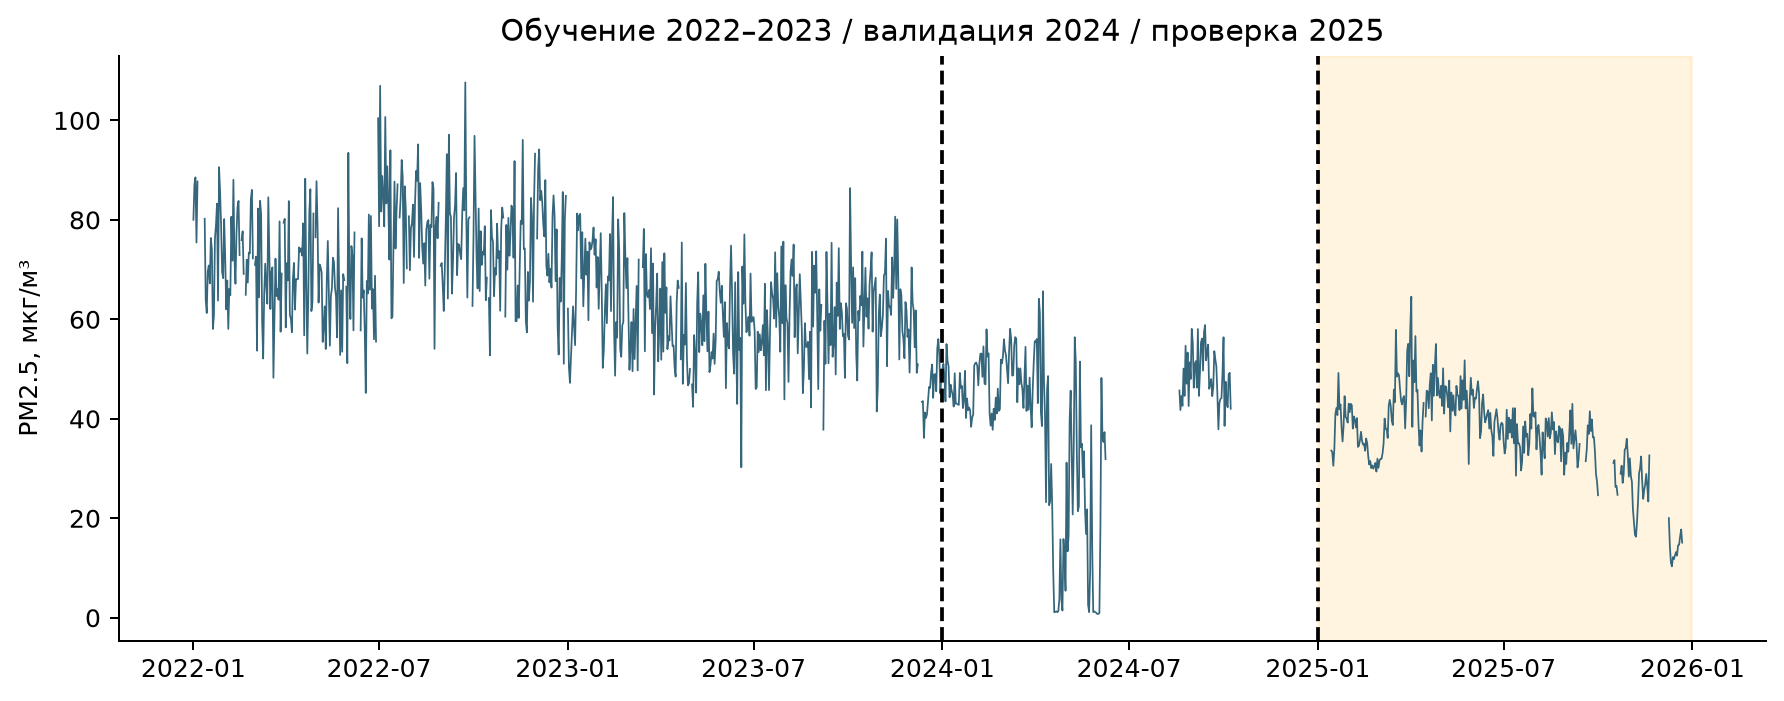

In [8]:
display(Image(filename=str(case / 'figures' / 'temporal_split.png')))

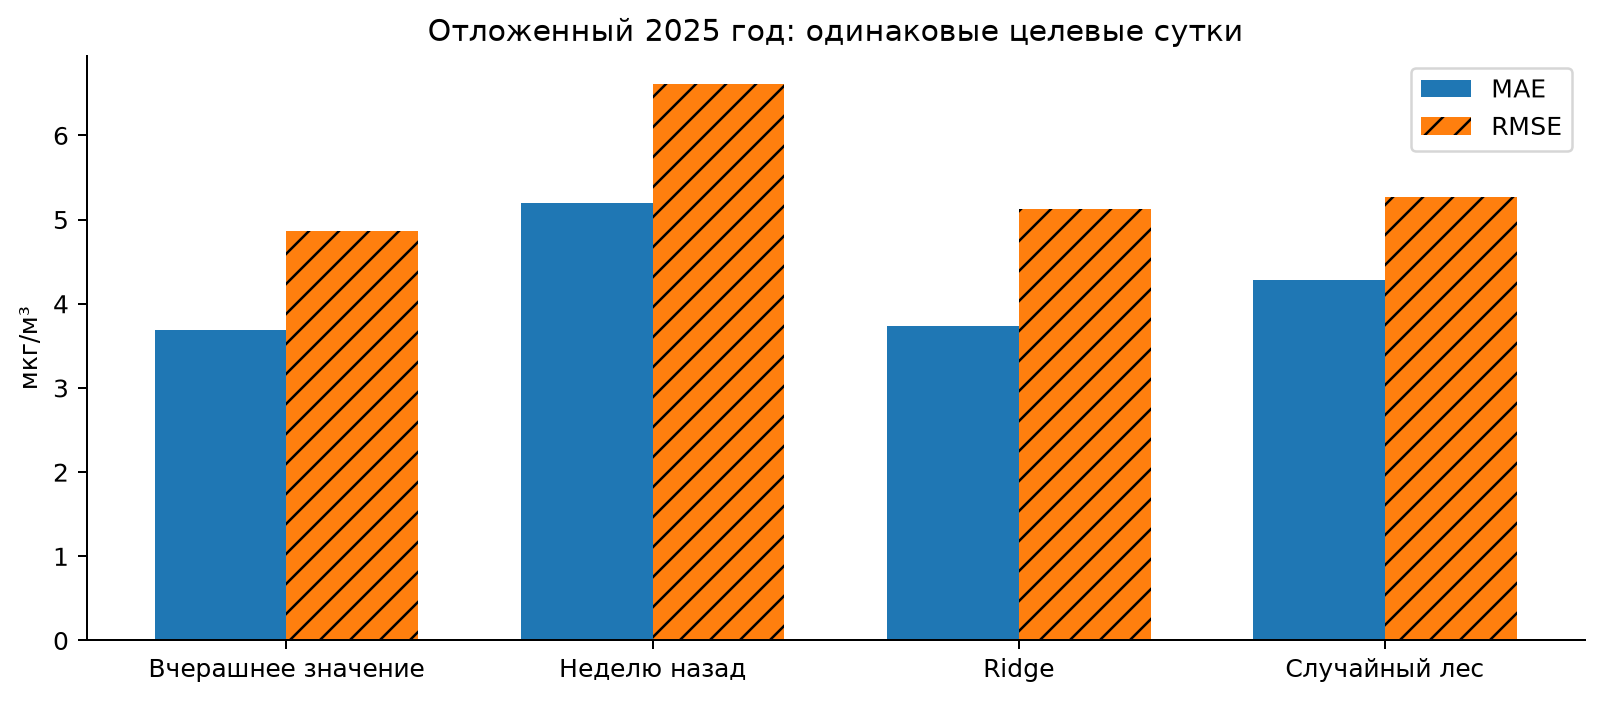

In [9]:
display(Image(filename=str(case / 'figures' / 'model_comparison.png')))

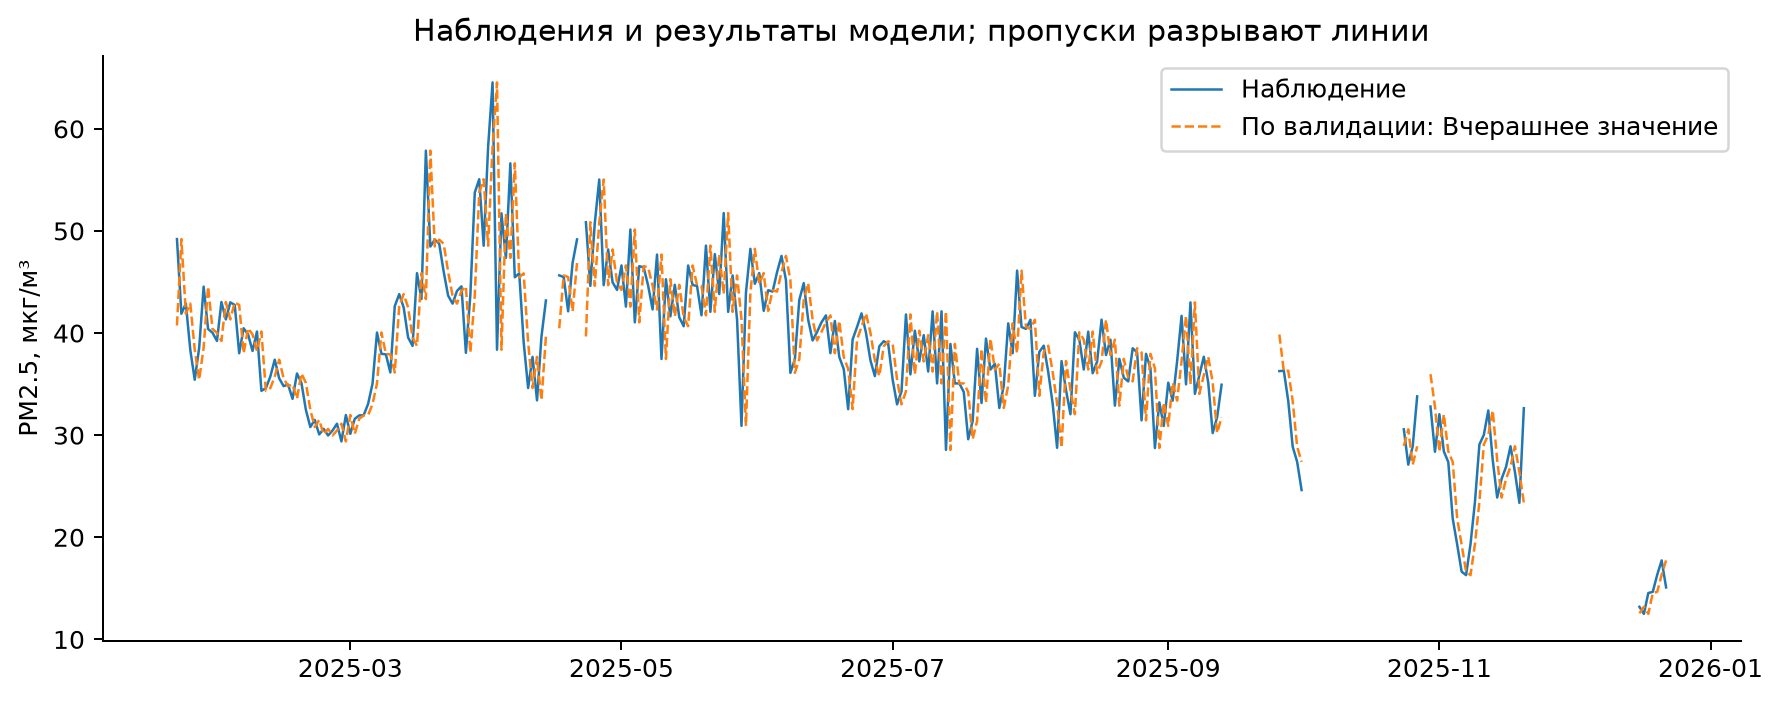

In [10]:
display(Image(filename=str(case / 'figures' / 'actual_predicted.png')))

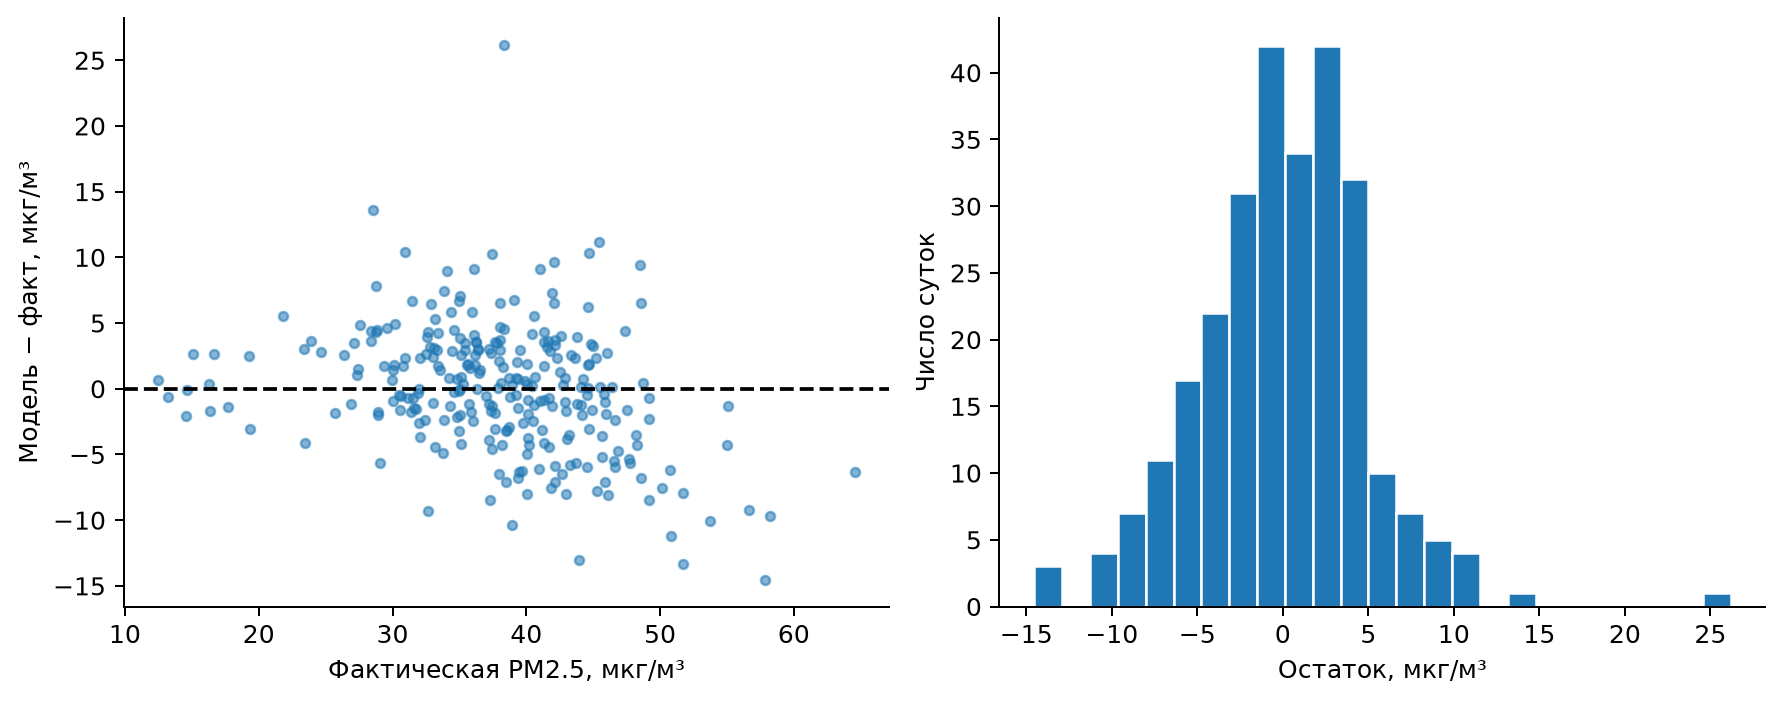

In [11]:
display(Image(filename=str(case / 'figures' / 'residuals.png')))

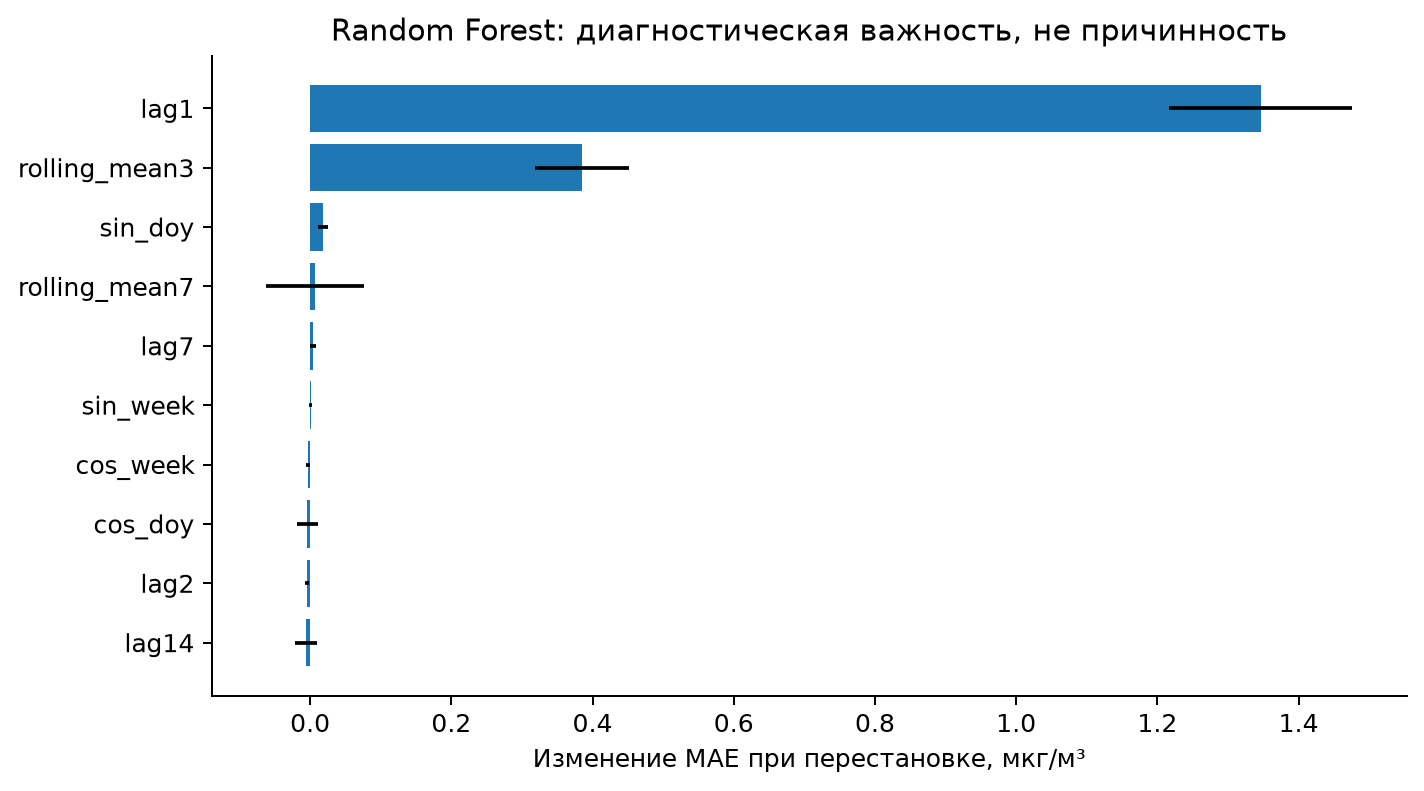

In [12]:
display(Image(filename=str(case / 'figures' / 'feature_importance.png')))

## Аудит и воспроизводимость

In [13]:
display(pd.read_csv(case/'results/quality_checks.csv'))
metadata = json.loads((case/'models/metadata.json').read_text(encoding='utf8'))
display(metadata['versions'])
print('Dataset SHA-256:', metadata['dataset_sha256'])
print('Validation selection:', metadata['selected_on_validation_MAE'])
print('Source limitation:', metadata['upstream_QC_caveat'])

,check,status
0,chronological_nonoverlap,PASS
1,no_imputed_target,PASS
2,identical_test_targets_all_models,PASS
3,metric_recalculation,PASS
4,publisher_realtime_availability,NOT_VERIFIABLE
5,station32_PM_fraction_physical_consistency,FAIL
6,all_model_features_strictly_before_target_start,PASS


{'python': '3.12.14',
 'numpy': '2.3.5',
 'pandas': '3.0.1',
 'sklearn': '1.9.1',
 'scipy': '1.18.1'}

Dataset SHA-256: 94bfa1d46e3f3767816f7a0b673e5bc64f9bf724aacb90da952356092918b0ee
Validation selection: persistence
Source limitation: Retrospective publisher filtering and measurement availability latency not reconstructable; offline benchmark only.


## Вывод

Реально обученные альтернативы не дали устойчивого выигрыша над заранее предусмотренным baseline. Все цифры выше получены выполненным кодом. Нужны независимая проверка канала и сведения о фактическом времени публикации измерений. Подробная интерпретация и источники — в Report.md и References.md.